In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
def objective_function(x):

    return np.sum(x ** 2)

In [38]:
def initialize_population(
    pop_size,
    dim,
    lower_bound,
    upper_bound
):

    return np.random.uniform(
        lower_bound,
        upper_bound,
        (pop_size, dim)
    )

In [40]:
def evaluate_population(population):

    return np.array([
        objective_function(ind)
        for ind in population
    ])

In [42]:
def clone_population(selected, clone_factor):

    clones = []

    for i, antibody in enumerate(selected):

        num_clones = int(
            clone_factor / (i + 1)
        )

        clones.extend([
            antibody.copy()
            for _ in range(num_clones)
        ])

    return np.array(clones)

In [44]:
def hypermutation(
    clones,
    beta,
    lower_bound,
    upper_bound
):

    mutated = []

    for clone in clones:

        mutation_rate = (
            beta *
            np.exp(-objective_function(clone))
        )

        new_clone = (
            clone
            +
            mutation_rate *
            np.random.randn(*clone.shape)
        )

        new_clone = np.clip(
            new_clone,
            lower_bound,
            upper_bound
        )

        mutated.append(new_clone)

    return np.array(mutated)

In [46]:
def replace_population(
    population,
    new_cells,
    pop_size
):

    combined = np.vstack((
        population,
        new_cells
    ))

    fitness = evaluate_population(combined)

    sorted_indices = np.argsort(fitness)

    return combined[
        sorted_indices[:pop_size]
    ]

In [48]:
def clonalg(
    pop_size=50,
    dim=5,
    generations=100,
    lower_bound=-5,
    upper_bound=5,
    selection_size=10,
    clone_factor=20,
    beta=1.0
):

    population = initialize_population(
        pop_size,
        dim,
        lower_bound,
        upper_bound
    )

    best_fitness_history = []

    for gen in range(generations):

        fitness = evaluate_population(population)

        sorted_indices = np.argsort(fitness)

        population = population[sorted_indices]

        selected = population[:selection_size]

        clones = clone_population(
            selected,
            clone_factor
        )

        mutated_clones = hypermutation(
            clones,
            beta,
            lower_bound,
            upper_bound
        )

        population = replace_population(
            population,
            mutated_clones,
            pop_size
        )

        best_fitness = objective_function(
            population[0]
        )

        best_fitness_history.append(best_fitness)

        if gen % 10 == 0:

            print(
                f"Generation {gen}: "
                f"Best Fitness = "
                f"{best_fitness:.6f}"
            )

    return population[0], best_fitness_history

In [50]:
best_solution, history = clonalg()

print("\nBest Solution:")
print(best_solution)

print("\nBest Fitness:")
print(objective_function(best_solution))

Generation 0: Best Fitness = 5.728587
Generation 10: Best Fitness = 5.343690
Generation 20: Best Fitness = 4.697083
Generation 30: Best Fitness = 3.657479
Generation 40: Best Fitness = 0.112012
Generation 50: Best Fitness = 0.061853
Generation 60: Best Fitness = 0.061853
Generation 70: Best Fitness = 0.061853
Generation 80: Best Fitness = 0.061853
Generation 90: Best Fitness = 0.061853

Best Solution:
[ 0.12137681 -0.13567352 -0.06185209  0.03852225 -0.15298263]

Best Fitness:
0.061852962901222726


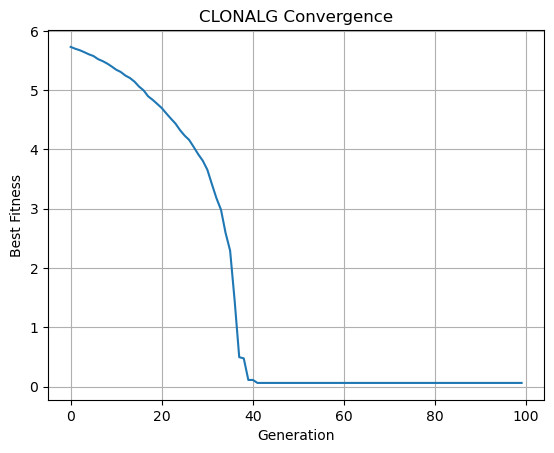

In [52]:
plt.plot(history)

plt.title("CLONALG Convergence")

plt.xlabel("Generation")

plt.ylabel("Best Fitness")

plt.grid()

plt.show()